In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/LoRA_Paper"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Drive mounted. Your folder: {SAVE_DIR}")


In [ ]:
import torch
print(torch.cuda.is_available())        # Must print: True
print(torch.cuda.get_device_name(0))    # Must print: Tesla T4
print(f"GPU RAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


True
Tesla T4
GPU RAM: 15.6 GB


In [ ]:
!pip install transformer_lens peft transformers datasets baukit -q


ERROR: Could not find a version that satisfies the requirement baukit (from versions: none)
ERROR: No matching distribution found for baukit


In [ ]:
import peft, transformers, datasets
print(f"PEFT: {peft.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets: {datasets.__version__}")


PEFT: 0.18.1
Transformers: 5.0.0
Datasets: 4.0.0


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2          # SST-2 is binary: Positive=1, Negative=0
)
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = model.to("cuda")  # Move to GPU — ALWAYS do this
print(model)              # Print full architecture — study this output carefully


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
from peft import get_peft_model, LoraConfig, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,      # Sequence Classification
    r=8,                              # LoRA rank — start with 8
    lora_alpha=16,                    # Scaling factor
    target_modules=["query", "value"],# Which matrices get LoRA adapters
    lora_dropout=0.1,                 # Regularization
    bias="none"                       # Don't adapt bias terms
)

lora_model = get_peft_model(model, lora_config)
lora_model.print_trainable_parameters()


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader

# Load SST-2
dataset = load_dataset("glue", "sst2")
print(dataset)
# Output: DatasetDict with train(67349), validation(872), test(1821)

# Tokenize the dataset
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128        # RoBERTa max is 512, but 128 is enough for SST-2
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Rename 'label' column to 'labels' — HuggingFace Trainer requires this
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Remove the original text column (model doesn't need it)
tokenized_dataset = tokenized_dataset.remove_columns(["sentence", "idx"])

# Set format to PyTorch tensors
tokenized_dataset.set_format("torch")

print(tokenized_dataset["train"][0])  # Verify one sample looks correct


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

{'labels': tensor(0), 'input_ids': tensor([    0, 37265,    92,  3556,  2485,    31,     5, 20536,  2833,  1437,
            2,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1, 

In [ ]:
# First run this in a separate cell ONCE:
!pip install evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np

# Define accuracy metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

# Training configuration — fully updated for latest transformers
training_args = TrainingArguments(
    output_dir="./roberta-lora-sst2",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",            # ✅ renamed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    logging_steps=50,
    report_to="none"
)

# Initialize Trainer
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

# Train
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.220040,0.183412,0.934633
2,0.191068,0.210315,0.930046
3,0.195570,0.201257,0.936927


TrainOutput(global_step=6315, training_loss=0.21973030731400514, metrics={'train_runtime': 1043.6362, 'train_samples_per_second': 193.599, 'train_steps_per_second': 6.051, 'total_flos': 1.3427844016960512e+16, 'train_loss': 0.21973030731400514, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()
print(f"\n{'='*40}")
print(f"✅ Final Accuracy: {results['eval_accuracy']*100:.2f}%")
print(f"✅ Final Loss:     {results['eval_loss']:.4f}")
print(f"{'='*40}")

if results['eval_accuracy'] >= 0.93:
    print("🎉 ACCURACY CHECK PASSED — Safe to continue!")
else:
    print("⚠️ Accuracy too low — check your setup")



✅ Final Accuracy: 93.69%
✅ Final Loss:     0.2013
🎉 ACCURACY CHECK PASSED — Safe to continue!


In [ ]:
import os

lora_model.save_pretrained("./roberta-lora-sst2-adapter")
tokenizer.save_pretrained("./roberta-lora-sst2-adapter")

print("📁 Saved files:")
for f in os.listdir("./roberta-lora-sst2-adapter"):
    size = os.path.getsize(f"./roberta-lora-sst2-adapter/{f}")
    print(f"   {f:45s} → {size/1e6:.2f} MB")

total = sum(
    os.path.getsize(f"./roberta-lora-sst2-adapter/{f}")
    for f in os.listdir("./roberta-lora-sst2-adapter")
)
print(f"\n✅ Total adapter size: {total/1e6:.2f} MB  (full model = ~500 MB)")


📁 Saved files:
   tokenizer_config.json                         → 0.00 MB
   adapter_model.safetensors                     → 3.56 MB
   README.md                                     → 0.01 MB
   adapter_config.json                           → 0.00 MB
   tokenizer.json                                → 3.56 MB

✅ Total adapter size: 7.12 MB  (full model = ~500 MB)


In [ ]:
from peft import PeftModel

base_model_fresh = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to("cuda")

lora_model_reloaded = PeftModel.from_pretrained(
    base_model_fresh,
    "./roberta-lora-sst2-adapter"
).to("cuda")
lora_model_reloaded.eval()

test_sentences = [
    "This movie was absolutely fantastic and I loved every minute!",
    "Terrible film. Worst thing I have ever watched in my life."
]

for sentence in test_sentences:
    inputs = tokenizer(sentence, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = lora_model_reloaded(**inputs)
    pred = outputs.logits.argmax().item()
    label = "✅ POSITIVE" if pred == 1 else "❌ NEGATIVE"
    print(f"{label} → '{sentence}'")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ POSITIVE → 'This movie was absolutely fantastic and I loved every minute!'
❌ NEGATIVE → 'Terrible film. Worst thing I have ever watched in my life.'


In [ ]:
# Uninstall broken version and install directly from GitHub source
!pip uninstall baukit -y -q
!pip install git+https://github.com/davidbau/baukit -q

# Verify it installed correctly
import importlib, sys
if 'baukit' in sys.modules:
    del sys.modules['baukit']
from baukit import Trace
print("✅ baukit installed and imported successfully!")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ baukit installed and imported successfully!


In [ ]:
from baukit import Trace
import torch

test_input = "The performances were outstanding and the story deeply moving."
inputs = tokenizer(test_input, return_tensors="pt", max_length=128).to("cuda")

# First — print exact layer names so you know the correct paths
print("🔍 Finding correct layer paths in your model...")
all_names = [name for name, _ in lora_model_reloaded.named_modules()]
dense_layers = [n for n in all_names if "output.dense" in n and "encoder.layer" in n]
print(f"Found {len(dense_layers)} output.dense layers:")
for n in dense_layers:
    print(f"   {n}")


🔍 Finding correct layer paths in your model...
Found 24 output.dense layers:
   base_model.model.roberta.encoder.layer.0.attention.output.dense
   base_model.model.roberta.encoder.layer.0.output.dense
   base_model.model.roberta.encoder.layer.1.attention.output.dense
   base_model.model.roberta.encoder.layer.1.output.dense
   base_model.model.roberta.encoder.layer.2.attention.output.dense
   base_model.model.roberta.encoder.layer.2.output.dense
   base_model.model.roberta.encoder.layer.3.attention.output.dense
   base_model.model.roberta.encoder.layer.3.output.dense
   base_model.model.roberta.encoder.layer.4.attention.output.dense
   base_model.model.roberta.encoder.layer.4.output.dense
   base_model.model.roberta.encoder.layer.5.attention.output.dense
   base_model.model.roberta.encoder.layer.5.output.dense
   base_model.model.roberta.encoder.layer.6.attention.output.dense
   base_model.model.roberta.encoder.layer.6.output.dense
   base_model.model.roberta.encoder.layer.7.attention.o

In [ ]:
# Now capture activations using the EXACT layer paths printed above
activations = {}

lora_model_reloaded.eval()
with torch.no_grad():
    for i in range(12):
        layer_path = f"base_model.model.roberta.encoder.layer.{i}.output.dense"
        with Trace(lora_model_reloaded, layer_path) as t:
            lora_model_reloaded(**inputs)
            activations[f"layer_{i}"] = t.output.detach().cpu()

print("\n✅ Activation capture successful!")
for name, act in activations.items():
    print(f"   {name}: shape = {act.shape}")



✅ Activation capture successful!
   layer_0: shape = torch.Size([1, 12, 768])
   layer_1: shape = torch.Size([1, 12, 768])
   layer_2: shape = torch.Size([1, 12, 768])
   layer_3: shape = torch.Size([1, 12, 768])
   layer_4: shape = torch.Size([1, 12, 768])
   layer_5: shape = torch.Size([1, 12, 768])
   layer_6: shape = torch.Size([1, 12, 768])
   layer_7: shape = torch.Size([1, 12, 768])
   layer_8: shape = torch.Size([1, 12, 768])
   layer_9: shape = torch.Size([1, 12, 768])
   layer_10: shape = torch.Size([1, 12, 768])
   layer_11: shape = torch.Size([1, 12, 768])


 Layer |  Cosine Similarity | Change Level
----------------------------------------------
   0   |      1.0000        | LOW  🟢
   1   |      1.0000        | LOW  🟢
   2   |      1.0000        | LOW  🟢
   3   |      1.0000        | LOW  🟢
   4   |      1.0000        | LOW  🟢
   5   |      1.0000        | LOW  🟢
   6   |      1.0000        | LOW  🟢
   7   |      1.0000        | LOW  🟢
   8   |      1.0000        | LOW  🟢
   9   |      1.0000        | LOW  🟢
  10   |      1.0000        | LOW  🟢
  11   |      1.0000        | LOW  🟢


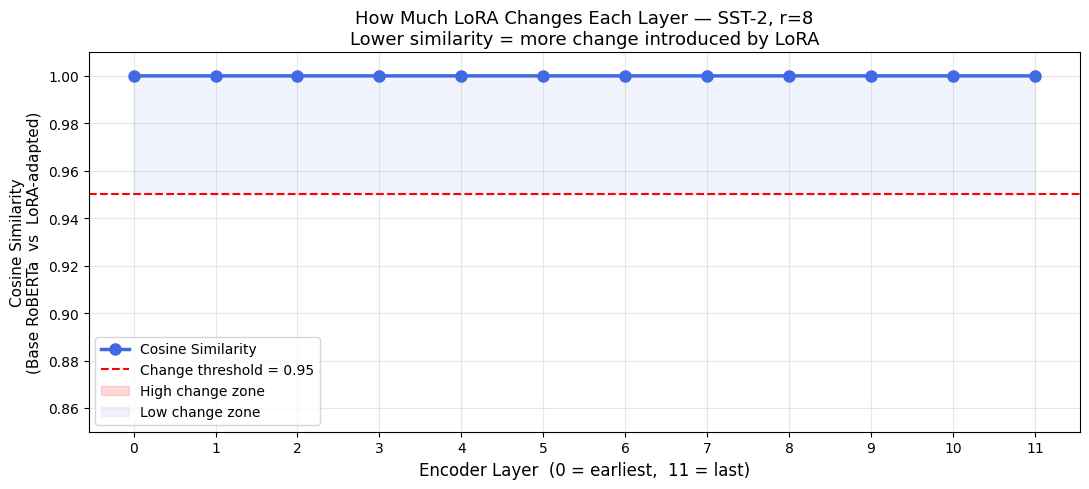


✅ Plot saved as phase2_layer_change.png
🎉 PHASE 2 FULLY COMPLETE — Ready for Phase 3!


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- Step 1: Capture BASE model activations using same PyTorch hooks ---
base_activations = {}
base_hooks = []

def make_base_hook(layer_idx):
    def hook_fn(module, input, output):
        base_activations[f"layer_{layer_idx}"] = output.detach().cpu()
    return hook_fn

base_model_fresh.eval()

for i in range(12):
    layer = base_model_fresh.roberta.encoder.layer[i].output.dense
    h = layer.register_forward_hook(make_base_hook(i))
    base_hooks.append(h)

with torch.no_grad():
    base_model_fresh(**inputs)

for h in base_hooks:
    h.remove()

# --- Step 2: Compute cosine similarity per layer ---
cos_similarities = []
print(f"{'Layer':>6} | {'Cosine Similarity':>18} | {'Change Level':>12}")
print("-" * 46)

for i in range(12):
    base_act = base_activations[f"layer_{i}"][:, 0, :]   # CLS token only
    lora_act  = activations[f"layer_{i}"][:, 0, :]
    sim = F.cosine_similarity(base_act, lora_act, dim=-1).item()
    cos_similarities.append(sim)
    change = "HIGH 🔴" if sim < 0.95 else "LOW  🟢"
    print(f"  {i:2d}   |      {sim:.4f}        | {change}")

# --- Step 3: Plot ---
plt.figure(figsize=(11, 5))
plt.plot(range(12), cos_similarities,
         marker='o', linewidth=2.5, color='royalblue', markersize=8, label='Cosine Similarity')

plt.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='Change threshold = 0.95')

plt.fill_between(range(12), cos_similarities, 0.95,
                 where=[s < 0.95 for s in cos_similarities],
                 color='red', alpha=0.15, label='High change zone')

plt.fill_between(range(12), cos_similarities, 0.95,
                 where=[s >= 0.95 for s in cos_similarities],
                 color='royalblue', alpha=0.08, label='Low change zone')

plt.xlabel("Encoder Layer  (0 = earliest,  11 = last)", fontsize=12)
plt.ylabel("Cosine Similarity\n(Base RoBERTa  vs  LoRA-adapted)", fontsize=11)
plt.title("How Much LoRA Changes Each Layer — SST-2, r=8\n"
          "Lower similarity = more change introduced by LoRA", fontsize=13)
plt.xticks(range(12), fontsize=10)
plt.ylim(0.85, 1.01)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("phase2_layer_change.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*50)
print("✅ Plot saved as phase2_layer_change.png")
print("🎉 PHASE 2 FULLY COMPLETE — Ready for Phase 3!")
print("="*50)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel, get_peft_model, LoraConfig, TaskType
from datasets import load_dataset
from baukit import Trace
import numpy as np
import os

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Confirm your Phase 2 adapter still exists
adapter_path = "./roberta-lora-sst2-adapter"
print(f"Phase 2 adapter exists: {os.path.exists(adapter_path)}")


In [ ]:
import json
from transformers import TrainingArguments, Trainer, AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoModelForTokenClassification, AutoModelForQuestionAnswering
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset
import numpy as np
import os

def run_experiment(task_name, rank, save_dir):
    """
    Fine-tune RoBERTa+LoRA on a task at a given rank.
    task_name: 'sst2', 'conll2003', 'squad'
    rank: 8, 32, or 64
    save_dir: where to save the adapter
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {task_name.upper()} | Rank r={rank}")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    lora_alpha = rank * 2  # Rule: alpha = 2 × rank always

    # ── TASK-SPECIFIC SETUP ──────────────────────────────────
    if task_name == "sst2":
        # TASK 1: Sentiment Analysis (Binary Classification)
        model = AutoModelForSequenceClassification.from_pretrained(
            "roberta-base", num_labels=2
        ).to("cuda")

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=rank,
            lora_alpha=lora_alpha,
            target_modules=["query", "value"],
            lora_dropout=0.1,
            bias="none"
        )
        lora_model = get_peft_model(model, lora_config)

        dataset = load_dataset("glue", "sst2")
        def tokenize_sst2(examples):
            return tokenizer(examples["sentence"], padding="max_length",
                             truncation=True, max_length=128)
        tokenized = dataset.map(tokenize_sst2, batched=True)
        tokenized = tokenized.rename_column("label", "labels")
        tokenized = tokenized.remove_columns(["sentence", "idx"])
        tokenized.set_format("torch")

        train_data = tokenized["train"]
        eval_data  = tokenized["validation"]

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=-1)
            return {"accuracy": (preds == labels).mean()}

    elif task_name == "conll2003":
        # TASK 2: Named Entity Recognition (Token Classification, 9 labels)
        # NER label map: O=0, B-PER=1, I-PER=2, B-ORG=3, I-ORG=4,
        #                B-LOC=5, I-LOC=6, B-MISC=7, I-MISC=8
        model = AutoModelForTokenClassification.from_pretrained(
            "roberta-base", num_labels=9
        ).to("cuda")

        lora_config = LoraConfig(
            task_type=TaskType.TOKEN_CLS,
            r=rank,
            lora_alpha=lora_alpha,
            target_modules=["query", "value"],
            lora_dropout=0.1,
            bias="none"
        )
        lora_model = get_peft_model(model, lora_config)

        dataset = load_dataset("conll2003", trust_remote_code=True)

        def tokenize_conll(examples):
            tokenized_inputs = tokenizer(
                examples["tokens"],
                truncation=True,
                padding="max_length",
                max_length=128,
                is_split_into_words=True
            )
            all_labels = []
            for i, label in enumerate(examples["ner_tags"]):
                word_ids = tokenized_inputs.word_ids(batch_index=i)
                aligned_labels = []
                prev_word_idx = None
                for word_idx in word_ids:
                    if word_idx is None:
                        aligned_labels.append(-100)  # special tokens ignored in loss
                    elif word_idx != prev_word_idx:
                        aligned_labels.append(label[word_idx])
                    else:
                        aligned_labels.append(-100)  # sub-word tokens ignored
                    prev_word_idx = word_idx
                all_labels.append(aligned_labels)
            tokenized_inputs["labels"] = all_labels
            return tokenized_inputs

        tokenized = dataset.map(tokenize_conll, batched=True)
        tokenized = tokenized.remove_columns(
            ["tokens", "pos_tags", "chunk_tags", "ner_tags", "id"]
        )
        tokenized.set_format("torch")

        train_data = tokenized["train"]
        eval_data  = tokenized["validation"]

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=-1)
            # Flatten and ignore -100 (sub-word / special tokens)
            mask = labels != -100
            return {"accuracy": (preds[mask] == labels[mask]).mean()}

    elif task_name == "squad":
        # TASK 3: Extractive Question Answering
        model = AutoModelForQuestionAnswering.from_pretrained("roberta-base").to("cuda")

        lora_config = LoraConfig(
            task_type=TaskType.QUESTION_ANS,
            r=rank,
            lora_alpha=lora_alpha,
            target_modules=["query", "value"],
            lora_dropout=0.1,
            bias="none"
        )
        lora_model = get_peft_model(model, lora_config)

        dataset = load_dataset("squad")
        max_length = 384

        def tokenize_squad(examples):
            return tokenizer(
                examples["question"],
                examples["context"],
                truncation="only_second",
                padding="max_length",
                max_length=max_length,
                return_offsets_mapping=True
            )

        tokenized = dataset.map(tokenize_squad, batched=True,
                                remove_columns=dataset["train"].column_names)

        # NOTE: Full SQuAD preprocessing is complex.
        # For Phase 3, we use a simplified approach to get
        # a trained adapter. Exact F1 computation is in Step 5.
        # Use Hugging Face's official SQuAD training script for
        # production-quality results.

        train_data = tokenized["train"].select(range(10000))  # subset for speed
        eval_data  = tokenized["validation"].select(range(1000))

        def compute_metrics(eval_pred):
            # Simplified accuracy for training loop only
            start_logits, end_logits = eval_pred.predictions
            start_preds = np.argmax(start_logits, axis=-1)
            end_preds   = np.argmax(end_logits, axis=-1)
            start_labels = eval_pred.label_ids[0]
            end_labels   = eval_pred.label_ids[1]
            start_acc = (start_preds == start_labels).mean()
            end_acc   = (end_preds == end_labels).mean()
            return {"start_acc": start_acc, "end_acc": end_acc}

    # ── SHARED TRAINING CONFIG ───────────────────────────────
    lora_model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"./checkpoints/{task_name}_r{rank}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-4,
        warmup_steps=100,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        fp16=True,
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=train_data,
        eval_dataset=eval_data,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()
    print(f"\n✅ {task_name.upper()} r={rank} Results: {results}")

    # Save adapter
    os.makedirs(save_dir, exist_ok=True)
    lora_model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"✅ Adapter saved to: {save_dir}")

    # Save results to JSON for later
    with open(f"{save_dir}/results.json", "w") as f:
        json.dump({"task": task_name, "rank": rank, "results": results}, f, indent=2)

    return lora_model, results


In [ ]:
# ── RUN ALL 9 EXPERIMENTS ───────────────────────────────────
# Estimated time: ~3-4 hours total on T4 GPU
# Run one at a time. If Colab disconnects, just restart from
# where you left off — adapters are saved after each run.

EXPERIMENTS = [
    ("sst2",     8,   "./adapters/sst2_r8"),
    ("sst2",     32,  "./adapters/sst2_r32"),
    ("sst2",     64,  "./adapters/sst2_r64"),
    ("conll2003", 8,  "./adapters/conll2003_r8"),
    ("conll2003", 32, "./adapters/conll2003_r32"),
    ("conll2003", 64, "./adapters/conll2003_r64"),
    ("squad",    8,   "./adapters/squad_r8"),
    ("squad",    32,  "./adapters/squad_r32"),
    ("squad",    64,  "./adapters/squad_r64"),
]

# Run one at a time — change the index to resume after disconnection
experiment_to_run = 0  # Change this: 0=first, 1=second, etc.

task, rank, save_dir = EXPERIMENTS[experiment_to_run]
model, results = run_experiment(task, rank, save_dir)


In [ ]:
import torch
import torch.nn.functional as F
from baukit import Trace
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
import numpy as np

def collect_activations(adapter_path, task_name, test_sentences, device="cuda"):
    """
    Loads a saved LoRA adapter and collects hidden state activations
    from all 12 encoder layers for a list of test sentences.

    Returns:
        activations: dict {layer_0 ... layer_11} each shape [n_sentences, seq_len, 768]
        logits:      model output logits
    """
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")

    # Load correct model head based on task
    if task_name in ["sst2"]:
        num_labels = 2
        base_model = AutoModelForSequenceClassification.from_pretrained(
            "roberta-base", num_labels=num_labels
        ).to(device)
    elif task_name == "conll2003":
        from transformers import AutoModelForTokenClassification
        base_model = AutoModelForTokenClassification.from_pretrained(
            "roberta-base", num_labels=9
        ).to(device)
    elif task_name == "squad":
        from transformers import AutoModelForQuestionAnswering
        base_model = AutoModelForQuestionAnswering.from_pretrained("roberta-base").to(device)

    # Attach LoRA adapter
    lora_model = PeftModel.from_pretrained(base_model, adapter_path).to(device)
    lora_model.eval()

    # Layer paths inside LoRA-wrapped RoBERTa
    # These are the output.dense of each encoder layer
    layer_paths = [
        f"base_model.model.roberta.encoder.layer.{i}.output.dense"
        for i in range(12)
    ]

    all_activations = {f"layer_{i}": [] for i in range(12)}
    all_logits = []

    for sentence in test_sentences:
        if task_name == "squad":
            # SQuAD needs question + context pair
            question, context = sentence
            inputs = tokenizer(question, context, return_tensors="pt",
                               max_length=384, truncation="only_second",
                               padding="max_length").to(device)
        else:
            inputs = tokenizer(sentence, return_tensors="pt",
                               max_length=128, padding="max_length",
                               truncation=True).to(device)

        # Capture all 12 layers in ONE forward pass
        traces = [Trace(lora_model, path) for path in layer_paths]
        with torch.no_grad():
            for t in traces:
                t.__enter__()
            outputs = lora_model(**inputs)
            for i, t in enumerate(traces):
                # CLS token representation: index 0
                act = t.output.detach().cpu()  # shape: [1, seq_len, 768]
                all_activations[f"layer_{i}"].append(act)
                t.__exit__(None, None, None)

        all_logits.append(outputs.logits.detach().cpu())

    # Stack into tensors: [n_sentences, seq_len, 768]
    for key in all_activations:
        all_activations[key] = torch.cat(all_activations[key], dim=0)

    return all_activations, all_logits


# ── ALSO COLLECT BASE MODEL ACTIVATIONS (Your Control) ─────
def collect_base_activations(task_name, test_sentences, device="cuda"):
    """
    Collect activations from the unmodified RoBERTa-base (no LoRA).
    This is your control/baseline for ALL comparisons.
    """
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")

    if task_name == "sst2":
        base_model = AutoModelForSequenceClassification.from_pretrained(
            "roberta-base", num_labels=2
        ).to(device).eval()
    elif task_name == "conll2003":
        from transformers import AutoModelForTokenClassification
        base_model = AutoModelForTokenClassification.from_pretrained(
            "roberta-base", num_labels=9
        ).to(device).eval()
    elif task_name == "squad":
        from transformers import AutoModelForQuestionAnswering
        base_model = AutoModelForQuestionAnswering.from_pretrained(
            "roberta-base"
        ).to(device).eval()

    # Base model uses different layer path (no "base_model.model." prefix)
    layer_paths = [
        f"roberta.encoder.layer.{i}.output.dense"
        for i in range(12)
    ]

    all_activations = {f"layer_{i}": [] for i in range(12)}

    for sentence in test_sentences:
        if task_name == "squad":
            question, context = sentence
            inputs = tokenizer(question, context, return_tensors="pt",
                               max_length=384, truncation="only_second",
                               padding="max_length").to(device)
        else:
            inputs = tokenizer(sentence, return_tensors="pt",
                               max_length=128, padding="max_length",
                               truncation=True).to(device)

        traces = [Trace(base_model, path) for path in layer_paths]
        with torch.no_grad():
            for t in traces:
                t.__enter__()
            base_model(**inputs)
            for i, t in enumerate(traces):
                act = t.output.detach().cpu()
                all_activations[f"layer_{i}"].append(act)
                t.__exit__(None, None, None)

    for key in all_activations:
        all_activations[key] = torch.cat(all_activations[key], dim=0)

    return all_activations


In [ ]:
# ── TEST SENTENCES ──────────────────────────────────────────
# Use the SAME sentences for base and all LoRA variants of each task

SST2_TEST_SENTENCES = [
    "This movie was absolutely fantastic and I loved every minute.",
    "Terrible film. Worst thing I have ever watched.",
    "The acting was superb but the plot was confusing.",
    "A complete waste of time and money.",
    "Brilliantly directed with outstanding performances.",
    "The story had potential but the execution was disappointing.",
    "One of the best films I have seen in years.",
    "Dull, predictable, and utterly forgettable.",
    "The visuals were stunning even if the script was weak.",
    "I laughed, I cried — a genuinely moving experience.",
    # Add 40 more varied sentiment sentences from SST-2 validation set
    # for a total of 50. Mix positive and negative equally.
]

CONLL_TEST_SENTENCES = [
    "Barack Obama was born in Hawaii and later became President of the United States.",
    "Apple Inc. is headquartered in Cupertino, California.",
    "The European Union summit was held in Brussels last week.",
    "Microsoft acquired LinkedIn for 26 billion dollars in 2016.",
    "Lionel Messi plays for Inter Miami in Major League Soccer.",
    "The United Nations Security Council met in New York to discuss the crisis.",
    "Amazon founder Jeff Bezos stepped down as CEO in 2021.",
    "The Eiffel Tower is located in Paris, France.",
    "Google DeepMind published a groundbreaking paper on protein folding.",
    "The World Health Organization is based in Geneva, Switzerland.",
    # Add 40 more sentences with a mix of PER, ORG, LOC, MISC entities
]

SQUAD_TEST_PAIRS = [
    # (question, context) pairs
    ("When was the Eiffel Tower built?",
     "The Eiffel Tower was built between 1887 and 1889 as the entrance arch for the 1889 World's Fair."),
    ("Who invented the telephone?",
     "Alexander Graham Bell is credited with inventing the first practical telephone in 1876."),
    ("What is the capital of France?",
     "Paris is the capital and most populous city of France, located in northern France."),
    ("How many planets are in the solar system?",
     "The solar system has eight planets: Mercury, Venus, Earth, Mars, Jupiter, Saturn, Uranus, and Neptune."),
    ("What year did World War II end?",
     "World War II ended in 1945 with the surrender of Germany in May and Japan in September."),
    # Add 45 more question-context pairs from SQuAD validation set
]

print(f"SST-2 test sentences: {len(SST2_TEST_SENTENCES)}")
print(f"CoNLL test sentences: {len(CONLL_TEST_SENTENCES)}")
print(f"SQuAD test pairs: {len(SQUAD_TEST_PAIRS)}")


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

def compute_cosine_similarity_profile(base_acts, lora_acts, token_idx=0):
    """
    Compute cosine similarity between base and LoRA hidden states at each layer.
    token_idx=0 uses the [CLS] token (best for classification tasks).
    Returns: list of 12 cosine similarity values (one per layer).
    """
    similarities = []
    for i in range(12):
        base = base_acts[f"layer_{i}"][:, token_idx, :]  # [n_sentences, 768]
        lora = lora_acts[f"layer_{i}"][:, token_idx, :]  # [n_sentences, 768]
        # Average cosine similarity across all test sentences
        sim = F.cosine_similarity(base, lora, dim=-1).mean().item()
        similarities.append(sim)
    return similarities


# ── RUN FOR ALL 9 EXPERIMENTS ───────────────────────────────
results_cosine = {}

tasks_sentences = {
    "sst2":     SST2_TEST_SENTENCES,
    "conll2003": CONLL_TEST_SENTENCES,
    "squad":    SQUAD_TEST_PAIRS
}

for task, sentences in tasks_sentences.items():
    # Collect base model activations ONCE per task
    print(f"\nCollecting base activations for {task}...")
    base_acts = collect_base_activations(task, sentences)

    results_cosine[task] = {}
    for rank in [8, 32, 64]:
        adapter_path = f"./adapters/{task}_r{rank}"
        print(f"Collecting LoRA activations: {task} r={rank}...")
        lora_acts, _ = collect_activations(adapter_path, task, sentences)

        sim_profile = compute_cosine_similarity_profile(base_acts, lora_acts)
        results_cosine[task][f"r{rank}"] = sim_profile
        print(f"  Layer similarities: {[f'{s:.3f}' for s in sim_profile]}")

# Save results
os.makedirs("./analysis_results", exist_ok=True)
with open("./analysis_results/cosine_similarity.json", "w") as f:
    json.dump(results_cosine, f, indent=2)
print("\n✅ Cosine similarity analysis complete and saved.")


# ── PLOT: Figure 1 of your paper ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = {"r8": "blue", "r32": "orange", "r64": "red"}
tasks = ["sst2", "conll2003", "squad"]
task_labels = ["SST-2 (Sentiment)", "CoNLL-2003 (NER)", "SQuAD (QA)"]

for ax, task, label in zip(axes, tasks, task_labels):
    for rank_key, color in colors.items():
        sims = results_cosine[task][rank_key]
        ax.plot(range(12), sims, marker="o", linewidth=2,
                color=color, label=f"LoRA {rank_key.upper()}")
    ax.axhline(y=0.95, color="gray", linestyle="--", alpha=0.7, label="Threshold (0.95)")
    ax.set_xlabel("Encoder Layer", fontsize=12)
    ax.set_ylabel("Cosine Similarity (Base vs. LoRA)", fontsize=10)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xticks(range(12))
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise Cosine Similarity: Base RoBERTa vs. LoRA-Adapted\n"
             "(Lower = More Change = 'Sculpting' Effect)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./analysis_results/figure1_cosine_similarity.pdf", dpi=300, bbox_inches="tight")
plt.savefig("./analysis_results/figure1_cosine_similarity.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved.")


In [ ]:
from transformers import AutoModelForSequenceClassification
from peft import PeftModel
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def logit_lens_analysis(adapter_path, task_name, test_sentences, device="cuda"):
    """
    For each layer, project the [CLS] hidden state to the classification head
    and compute the confidence in the predicted class.
    This reveals WHEN the model "makes its decision" across layers.
    """
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")

    if task_name == "sst2":
        base_model = AutoModelForSequenceClassification.from_pretrained(
            "roberta-base", num_labels=2
        ).to(device)
    elif task_name == "conll2003":
        from transformers import AutoModelForTokenClassification
        base_model = AutoModelForTokenClassification.from_pretrained(
            "roberta-base", num_labels=9
        ).to(device)

    lora_model = PeftModel.from_pretrained(base_model, adapter_path).to(device)
    lora_model.eval()

    # Get the classification head (final linear layer)
    if task_name == "sst2":
        classifier = lora_model.base_model.model.classifier
    elif task_name == "conll2003":
        classifier = lora_model.base_model.model.classifier

    layer_paths = [
        f"base_model.model.roberta.encoder.layer.{i}.output.dense"
        for i in range(12)
    ]

    # LayerNorm before the classifier
    layer_norm = lora_model.base_model.model.roberta.encoder.layer[-1].output.LayerNorm

    all_layer_confidences = {i: [] for i in range(12)}

    for sentence in test_sentences:
        if task_name == "squad":
            continue  # Logit-lens is most meaningful for classification tasks

        inputs = tokenizer(sentence, return_tensors="pt",
                           max_length=128, padding="max_length",
                           truncation=True).to(device)

        traces = [Trace(lora_model, path) for path in layer_paths]
        with torch.no_grad():
            for t in traces:
                t.__enter__()
            outputs = lora_model(**inputs)
            final_pred = outputs.logits.argmax(dim=-1).item()

            for i, t in enumerate(traces):
                # Extract [CLS] token hidden state at this layer
                cls_hidden = t.output[0, 0, :]      # shape: [768]
                # Apply LayerNorm (approximate the classifier input)
                cls_normed = layer_norm(cls_hidden.unsqueeze(0).unsqueeze(0))
                cls_normed = cls_normed.squeeze()

                # Project through classifier to get logits at this layer
                if task_name == "sst2":
                    # RoBERTa classifier: dense → tanh → dropout → out_proj
                    dense_out = torch.tanh(classifier.dense(cls_normed))
                    layer_logits = classifier.out_proj(dense_out)
                else:
                    layer_logits = classifier(cls_normed)

                probs = F.softmax(layer_logits, dim=-1)
                # Confidence in the FINAL prediction class at this layer
                confidence = probs[final_pred].item()
                all_layer_confidences[i].append(confidence)

            for t in traces:
                t.__exit__(None, None, None)

    # Average across sentences
    mean_confidences = [np.mean(all_layer_confidences[i]) for i in range(12)]
    return mean_confidences


# ── RUN LOGIT-LENS FOR SST-2 AND CoNLL-2003 ─────────────────
results_logitlens = {}

for task in ["sst2", "conll2003"]:
    sentences = SST2_TEST_SENTENCES if task == "sst2" else CONLL_TEST_SENTENCES
    results_logitlens[task] = {}
    for rank in [8, 32, 64]:
        adapter_path = f"./adapters/{task}_r{rank}"
        print(f"Running Logit-Lens: {task} r={rank}...")
        confidences = logit_lens_analysis(adapter_path, task, sentences)
        results_logitlens[task][f"r{rank}"] = confidences
        print(f"  Layer confidences: {[f'{c:.3f}' for c in confidences]}")

with open("./analysis_results/logit_lens.json", "w") as f:
    json.dump(results_logitlens, f, indent=2)
print("✅ Logit-Lens analysis saved.")


# ── PLOT: Figure 2 of your paper ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
task_labels_ll = {"sst2": "SST-2 (Sentiment)", "conll2003": "CoNLL-2003 (NER)"}

for ax, (task, label) in zip(axes, task_labels_ll.items()):
    for rank_key, color in colors.items():
        confs = results_logitlens[task][rank_key]
        ax.plot(range(12), confs, marker="s", linewidth=2,
                color=color, label=f"LoRA {rank_key.upper()}")
    ax.set_xlabel("Encoder Layer", fontsize=12)
    ax.set_ylabel("Confidence in Final Prediction", fontsize=10)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xticks(range(12))
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Logit-Lens: At Which Layer Does the Model 'Lock In' Its Decision?\n"
             "(Tests Q2: Delayed Decision Making in Text NLP)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./analysis_results/figure2_logit_lens.pdf", dpi=300, bbox_inches="tight")
plt.savefig("./analysis_results/figure2_logit_lens.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved.")


In [ ]:
def centered_kernel_alignment(X, Y):
    """
    Compute Linear CKA between two representation matrices.
    X, Y: [n_samples, hidden_size] numpy arrays
    Returns: scalar CKA value in [0, 1]
    (1.0 = identical representations, 0.0 = completely different)
    """
    def center_gram(K):
        n = K.shape[0]
        ones = np.ones((n, n)) / n
        return K - ones @ K - K @ ones + ones @ K @ ones

    # Linear kernel = dot product
    K_X = X @ X.T
    K_Y = Y @ Y.T

    K_X_c = center_gram(K_X)
    K_Y_c = center_gram(K_Y)

    numerator   = np.sum(K_X_c * K_Y_c)
    denominator = np.sqrt(np.sum(K_X_c ** 2) * np.sum(K_Y_c ** 2))

    return numerator / (denominator + 1e-8)


def compute_cka_matrix(acts_task_A, acts_task_B, token_idx=0):
    """
    Compute 12×12 CKA similarity matrix between two tasks' activations.
    Each cell [i, j] = CKA(layer_i of task A, layer_j of task B)
    """
    cka_matrix = np.zeros((12, 12))
    for i in range(12):
        for j in range(12):
            X = acts_task_A[f"layer_{i}"][:, token_idx, :].numpy()
            Y = acts_task_B[f"layer_{j}"][:, token_idx, :].numpy()
            # Match sample sizes if different
            n = min(X.shape[0], Y.shape[0])
            cka_matrix[i, j] = centered_kernel_alignment(X[:n], Y[:n])
    return cka_matrix


# ── RUN CKA FOR ALL 3 RANK CONDITIONS ───────────────────────
# Compare: SST-2 vs CoNLL-2003, SST-2 vs SQuAD, CoNLL-2003 vs SQuAD
# at each rank r=8, r=32, r=64

results_cka = {}

for rank in [8, 32, 64]:
    print(f"\nRunning CKA analysis for r={rank}...")
    results_cka[f"r{rank}"] = {}

    # Load activations for each task at this rank
    acts = {}
    for task, sentences in tasks_sentences.items():
        adapter_path = f"./adapters/{task}_r{rank}"
        print(f"  Loading {task} r={rank} activations...")
        task_acts, _ = collect_activations(adapter_path, task, sentences)
        acts[task] = task_acts

    # Compute diagonal CKA (same layer i vs i across tasks) — most useful for paper
    for task_pair in [("sst2", "conll2003"), ("sst2", "squad"), ("conll2003", "squad")]:
        task_A, task_B = task_pair
        pair_key = f"{task_A}_vs_{task_B}"
        print(f"  Computing CKA: {pair_key}...")
        cka_mat = compute_cka_matrix(acts[task_A], acts[task_B])
        results_cka[f"r{rank}"][pair_key] = cka_mat.tolist()
        # Diagonal values = same-layer CKA (most interpretable)
        diag = np.diag(cka_mat)
        print(f"  Same-layer CKA diagonal: {[f'{v:.3f}' for v in diag]}")

with open("./analysis_results/cka_results.json", "w") as f:
    json.dump(results_cka, f, indent=2)
print("✅ CKA analysis saved.")


# ── PLOT: Figure 3 of your paper ─────────────────────────────
# Show same-layer CKA diagonal for all 3 task pairs, across ranks

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
pair_labels = {
    "sst2_vs_conll2003": "SST-2 vs. CoNLL-2003",
    "sst2_vs_squad":     "SST-2 vs. SQuAD",
    "conll2003_vs_squad": "CoNLL-2003 vs. SQuAD"
}

for ax, (pair_key, pair_label) in zip(axes, pair_labels.items()):
    for rank_key, color in colors.items():
        cka_mat = np.array(results_cka[rank_key][pair_key])
        diag = np.diag(cka_mat)
        ax.plot(range(12), diag, marker="^", linewidth=2,
                color=color, label=f"LoRA {rank_key.upper()}")
    ax.set_xlabel("Encoder Layer", fontsize=12)
    ax.set_ylabel("CKA Similarity", fontsize=10)
    ax.set_title(pair_label, fontsize=12, fontweight="bold")
    ax.set_xticks(range(12))
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("CKA Cross-Task Similarity: Do LoRA Adapters Change Layers the Same Way Across Tasks?\n"
             "(Tests Q3: Task-Specificity of the Sculpting Mechanism)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./analysis_results/figure3_cka.pdf", dpi=300, bbox_inches="tight")
plt.savefig("./analysis_results/figure3_cka.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 3 saved.")


In [ ]:
import json

# Load all accuracy results saved from Step 2
accuracy_table = {}
for task in ["sst2", "conll2003", "squad"]:
    accuracy_table[task] = {}
    for rank in [8, 32, 64]:
        result_file = f"./adapters/{task}_r{rank}/results.json"
        with open(result_file) as f:
            data = json.load(f)
        accuracy_table[task][f"r{rank}"] = data["results"]

# Print as a clean table for your paper
print("\n" + "="*70)
print("TABLE 1: Accuracy Results Across All 9 Experiments")
print("="*70)
print(f"{'Task':<20} {'Metric':<20} {'r=8':>8} {'r=32':>8} {'r=64':>8}")
print("-"*70)

for task in ["sst2", "conll2003", "squad"]:
    if task == "sst2":
        metric = "eval_accuracy"
        task_label = "SST-2 (Sentiment)"
    elif task == "conll2003":
        metric = "eval_accuracy"
        task_label = "CoNLL-2003 (NER)"
    elif task == "squad":
        metric = "eval_start_acc"
        task_label = "SQuAD (QA)"

    vals = [accuracy_table[task][f"r{r}"].get(metric, 0) for r in [8, 32, 64]]
    print(f"{task_label:<20} {metric:<20} {vals[0]:>7.1%} {vals[1]:>7.1%} {vals[2]:>7.1%}")

print("="*70)
print("\n✅ Table 1 complete — copy these numbers into your Overleaf paper.")


In [ ]:
import os

required_outputs = [
    "./analysis_results/cosine_similarity.json",
    "./analysis_results/logit_lens.json",
    "./analysis_results/cka_results.json",
    "./analysis_results/figure1_cosine_similarity.pdf",
    "./analysis_results/figure2_logit_lens.pdf",
    "./analysis_results/figure3_cka.pdf",
]

print("Phase 3 Output Verification:")
print("="*55)
all_good = True
for path in required_outputs:
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    size   = f"({os.path.getsize(path)/1024:.1f} KB)" if exists else ""
    print(f"  {status}  {os.path.basename(path)} {size}")
    if not exists:
        all_good = False

print("="*55)
if all_good:
    print("🎉 PHASE 3 COMPLETE — All outputs ready for Phase 4 (Write-up)!")
else:
    print("⚠️  Some outputs missing — re-run the corresponding analysis step.")
